## 1) Data Cleaning

Let's load up our data. We will cut down our pokedex to only include the Pokémon in our OU USG% CSV.
We also must normalize our data. Pokémon naturally have higher stats compared to other stats.

In [2]:
import pandas as pd
import numpy as np

ou_df = pd.read_csv('gen9ou-1500.csv', encoding='utf-8', engine='python')
dex_df = pd.read_json('pokedex.json', encoding='utf-8')

In [3]:
ou_df.head()
ou_df.columns

#It would be smart to remove Pokémon under a certain usage to keep it realistic.
#i.e. < 1% will be removed. Sorry Quagsire :(

threshold = 1.0
clean_ou = ou_df[ou_df['USG%'] > threshold]
clean_ou.head()

,Rank,Pokemon,USG%,Raw,Raw%,Real,Real%
0,1,Great Tusk,32.17450,583233,26.855,456210,26.592
1,2,Kingambit,20.89139,393073,18.099,266155,15.514
2,3,Gholdengo,19.16317,361370,16.639,276953,16.144
3,4,Ogerpon-Wellspring,17.69723,317672,14.627,254328,14.825
4,5,Dragapult,16.68244,343549,15.819,267046,15.566


In [4]:
dex_df.head()
dex_df.columns

Index(['num', 'name', 'types', 'genderRatio', 'baseStats', 'abilities',
       'heightm', 'weightkg', 'color', 'evos', 'eggGroups', 'prevo',
       'evoLevel', 'otherFormes', 'formeOrder', 'canGigantamax', 'baseSpecies',
       'forme', 'requiredItem', 'changesFrom', 'evoCondition', 'evoType',
       'gender', 'gen', 'evoItem', 'evoRegion', 'mother', 'canHatch',
       'evoMove', 'tags', 'baseForme', 'cosmeticFormes', 'maxHP',
       'requiredAbility', 'battleOnly', 'requiredMove', 'isCosmeticForme',
       'requiredItems', 'cannotDynamax', 'requiredTeraType'],
      dtype='object')

In [5]:
#Get the set of OU mons
ou_names = set(clean_ou['Pokemon'])

# Filter the dex to only mons in OU
ou_dex = dex_df[dex_df['name'].isin(ou_names)]
ou_dex = ou_dex.merge(clean_ou[['Pokemon', 'Rank']], left_on='name', right_on='Pokemon', how='inner')
ou_dex = ou_dex.sort_values('Rank')
ou_dex

,num,name,types,genderRatio,baseStats,abilities,heightm,weightkg,color,evos,...,maxHP,requiredAbility,battleOnly,requiredMove,isCosmeticForme,requiredItems,cannotDynamax,requiredTeraType,Pokemon,Rank
70,984.0,Great Tusk,"[Ground, Fighting]",NaN,"{'hp': 115, 'atk': 131, 'def': 131, 'spa': 53,...",{'0': 'Protosynthesis'},2.2,320.0,Purple,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Great Tusk,1
69,983.0,Kingambit,"[Dark, Steel]",NaN,"{'hp': 100, 'atk': 135, 'def': 120, 'spa': 60,...","{'0': 'Defiant', '1': 'Supreme Overlord', 'H':...",2.0,120.0,Black,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kingambit,2
75,1000.0,Gholdengo,"[Steel, Ghost]",NaN,"{'hp': 87, 'atk': 60, 'def': 95, 'spa': 133, '...",{'0': 'Good as Gold'},1.2,30.0,Yellow,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Gholdengo,3
81,1017.0,Ogerpon-Wellspring,"[Grass, Water]",NaN,"{'hp': 80, 'atk': 120, 'def': 84, 'spa': 60, '...",{'0': 'Water Absorb'},1.2,39.8,Blue,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Water,Ogerpon-Wellspring,4
54,887.0,Dragapult,"[Dragon, Ghost]",NaN,"{'hp': 88, 'atk': 120, 'def': 75, 'spa': 100, ...","{'0': 'Clear Body', '1': 'Infiltrator', 'H': '...",3.0,50.0,Green,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dragapult,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50,855.0,Polteageist,[Ghost],NaN,"{'hp': 60, 'atk': 65, 'def': 65, 'spa': 134, '...","{'0': 'Weak Armor', 'H': 'Cursed Body'}",0.2,0.4,Purple,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Polteageist,84
17,380.0,Latias,"[Dragon, Psychic]",NaN,"{'hp': 80, 'atk': 80, 'def': 90, 'spa': 110, '...",{'0': 'Levitate'},1.4,40.0,Red,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Latias,85
32,642.0,Thundurus-Therian,"[Electric, Flying]",NaN,"{'hp': 79, 'atk': 105, 'def': 70, 'spa': 145, ...",{'0': 'Volt Absorb'},3.0,61.0,Blue,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thundurus-Therian,86
62,925.0,Maushold,[Normal],NaN,"{'hp': 74, 'atk': 75, 'def': 70, 'spa': 65, 's...","{'0': 'Friend Guard', '1': 'Cheek Pouch', 'H':...",0.3,2.3,White,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Maushold,87


In [6]:
#To normalize, first we must flatten the stats out to their own columns.
stats_df = ou_dex['baseStats'].apply(pd.Series)
pokemon = pd.concat([ou_dex.drop(columns=['baseStats']), stats_df], axis=1)
pokemon

,num,name,types,genderRatio,abilities,heightm,weightkg,color,evos,eggGroups,...,cannotDynamax,requiredTeraType,Pokemon,Rank,hp,atk,def,spa,spd,spe
70,984.0,Great Tusk,"[Ground, Fighting]",NaN,{'0': 'Protosynthesis'},2.2,320.0,Purple,NaN,[Undiscovered],...,NaN,NaN,Great Tusk,1,115,131,131,53,53,87
69,983.0,Kingambit,"[Dark, Steel]",NaN,"{'0': 'Defiant', '1': 'Supreme Overlord', 'H':...",2.0,120.0,Black,NaN,[Human-Like],...,NaN,NaN,Kingambit,2,100,135,120,60,85,50
75,1000.0,Gholdengo,"[Steel, Ghost]",NaN,{'0': 'Good as Gold'},1.2,30.0,Yellow,NaN,[Undiscovered],...,NaN,NaN,Gholdengo,3,87,60,95,133,91,84
81,1017.0,Ogerpon-Wellspring,"[Grass, Water]",NaN,{'0': 'Water Absorb'},1.2,39.8,Blue,NaN,[Undiscovered],...,NaN,Water,Ogerpon-Wellspring,4,80,120,84,60,96,110
54,887.0,Dragapult,"[Dragon, Ghost]",NaN,"{'0': 'Clear Body', '1': 'Infiltrator', 'H': '...",3.0,50.0,Green,NaN,"[Amorphous, Dragon]",...,NaN,NaN,Dragapult,5,88,120,75,100,75,142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50,855.0,Polteageist,[Ghost],NaN,"{'0': 'Weak Armor', 'H': 'Cursed Body'}",0.2,0.4,Purple,NaN,"[Mineral, Amorphous]",...,NaN,NaN,Polteageist,84,60,65,65,134,114,70
17,380.0,Latias,"[Dragon, Psychic]",NaN,{'0': 'Levitate'},1.4,40.0,Red,NaN,[Undiscovered],...,NaN,NaN,Latias,85,80,80,90,110,130,110
32,642.0,Thundurus-Therian,"[Electric, Flying]",NaN,{'0': 'Volt Absorb'},3.0,61.0,Blue,NaN,[Undiscovered],...,NaN,NaN,Thundurus-Therian,86,79,105,70,145,80,101
62,925.0,Maushold,[Normal],NaN,"{'0': 'Friend Guard', '1': 'Cheek Pouch', 'H':...",0.3,2.3,White,NaN,"[Field, Fairy]",...,NaN,NaN,Maushold,87,74,75,70,65,75,111


In [7]:
#Now we scale.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
pokemon[['hp', 'atk', 'def', 'spa', 'spd', 'spe']] = scaler.fit_transform(pokemon[['hp', 'atk', 'def', 'spa', 'spd', 'spe']])
clean_pokemon = pokemon.drop(columns=['num', 'Pokemon', 'genderRatio', 'abilities', 'heightm', 'weightkg', 'color', 'evos', 'eggGroups', 'cannotDynamax', 'requiredTeraType', 'prevo', 'evoLevel', 'otherFormes', 'formeOrder', 'canGigantamax', 'baseSpecies', 'forme', 'requiredItem', 'changesFrom', 'isCosmeticForme', 'requiredItems', 'evoCondition', 'evoType', 'gender', 'gen', 'evoItem', 'evoRegion', 'mother', 'canHatch', 'requiredAbility', 'battleOnly', 'requiredMove', 'evoMove', 'tags', 'baseForme', 'cosmeticFormes', 'maxHP'])
clean_pokemon

,name,types,Rank,hp,atk,def,spa,spd,spe
70,Great Tusk,"[Ground, Fighting]",1,0.901875,1.252935,1.736859,-1.191354,-1.760704,0.028768
69,Kingambit,"[Dark, Steel]",2,0.383375,1.400240,1.268014,-0.968157,-0.200067,-1.203722
75,Gholdengo,"[Steel, Ghost]",3,-0.065991,-1.361740,0.202456,1.359477,0.092552,-0.071163
81,Ogerpon-Wellspring,"[Grass, Water]",4,-0.307957,0.847844,-0.266389,-0.968157,0.336401,0.794911
54,Dragapult,"[Dragon, Ghost]",5,-0.031424,0.847844,-0.649990,0.307259,-0.687766,1.860849
...,...,...,...,...,...,...,...,...,...
50,Polteageist,[Ghost],84,-0.999290,-1.177608,-1.076213,1.391363,1.214259,-0.537511
17,Latias,"[Dragon, Psychic]",85,-0.307957,-0.625212,-0.010656,0.626113,1.994578,0.794911
32,Thundurus-Therian,"[Electric, Flying]",86,-0.342524,0.295448,-0.863102,1.742102,-0.443917,0.495116
62,Maushold,[Normal],87,-0.515357,-0.809344,-0.863102,-0.808730,-0.687766,0.828221


## 2) Role Determination

We'll use k-means clustering to classify Pokémon into roles.

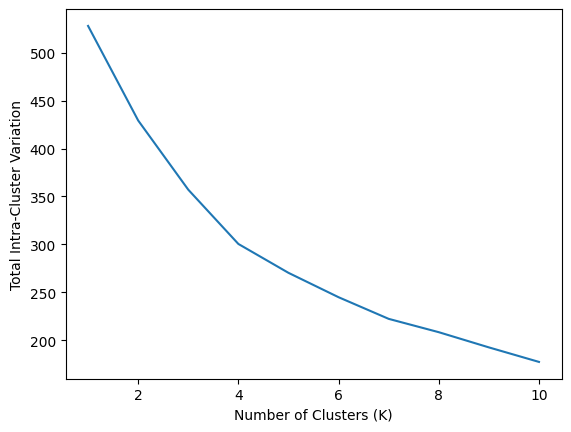

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
#Record the Total Intra-Cluster Variation
ticv = [] 

for k in range(1,11): 
    kmeans = KMeans(n_clusters=k, n_init=20)

    #Fit kmeans algorithm to the dataset
    kmeans.fit(clean_pokemon[['hp', 'atk', 'def', 'spa', 'spd', 'spe']])

    #Record the Total Intra-Cluster Variation for K=k
    ticv.append(kmeans.inertia_)
    

#Plot the elbow graph
plt.plot(range(1,11),ticv)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Total Intra-Cluster Variation')
plt.show()

In [9]:
#Based on the graph, the best k was 4, but that's a bit boring.
kmeans = KMeans(n_clusters=7, n_init=20, random_state=42)

kmeans.fit(clean_pokemon[['hp', 'atk', 'def', 'spa', 'spd', 'spe']])

clean_pokemon['kmeans_role'] = kmeans.labels_
clean_pokemon

,name,types,Rank,hp,atk,def,spa,spd,spe,kmeans_role
70,Great Tusk,"[Ground, Fighting]",1,0.901875,1.252935,1.736859,-1.191354,-1.760704,0.028768,6
69,Kingambit,"[Dark, Steel]",2,0.383375,1.400240,1.268014,-0.968157,-0.200067,-1.203722,3
75,Gholdengo,"[Steel, Ghost]",3,-0.065991,-1.361740,0.202456,1.359477,0.092552,-0.071163,0
81,Ogerpon-Wellspring,"[Grass, Water]",4,-0.307957,0.847844,-0.266389,-0.968157,0.336401,0.794911,4
54,Dragapult,"[Dragon, Ghost]",5,-0.031424,0.847844,-0.649990,0.307259,-0.687766,1.860849,4
...,...,...,...,...,...,...,...,...,...,...
50,Polteageist,[Ghost],84,-0.999290,-1.177608,-1.076213,1.391363,1.214259,-0.537511,0
17,Latias,"[Dragon, Psychic]",85,-0.307957,-0.625212,-0.010656,0.626113,1.994578,0.794911,0
32,Thundurus-Therian,"[Electric, Flying]",86,-0.342524,0.295448,-0.863102,1.742102,-0.443917,0.495116,2
62,Maushold,[Normal],87,-0.515357,-0.809344,-0.863102,-0.808730,-0.687766,0.828221,4


In [10]:
#We have the clusters, but what do they mean? Let's get the centroids and classify!
centroids = kmeans.cluster_centers_
centroids_real = scaler.inverse_transform(centroids)
centroids_df = pd.DataFrame(centroids_real, columns = ['hp', 'atk', 'def', 'spa', 'spd', 'spe'])
centroids_df.index.name = 'cluster'
centroids_df

,hp,atk,def,spa,spd,spe
cluster,,,,,,
0,83.904762,74.095238,94.619048,113.285714,102.000000,68.904762
1,91.882353,126.352941,86.705882,88.058824,80.588235,85.588235
2,81.000000,95.000000,76.750000,131.166667,94.416667,104.583333
3,79.000000,91.444444,132.444444,61.555556,86.111111,57.777778
4,74.428571,99.333333,77.809524,72.380952,85.476190,118.857143
5,255.000000,10.000000,10.000000,75.000000,135.000000,55.000000
6,142.714286,110.142857,103.428571,50.428571,70.142857,50.285714


In [11]:
#Let's manually classify them based on the centroids dataframe
roles = {
    0: "Special Tank",
    1: "Physical Wallbreaker",
    2: "Special Sweeper",
    3: "Physical Wall",
    4: "Physical Sweeper",
    5: "Special Wall/Sponge/Util",
    6: "Physical Tank"
}

clean_pokemon['role'] = clean_pokemon['kmeans_role'].map(roles)
clean_pokemon

,name,types,Rank,hp,atk,def,spa,spd,spe,kmeans_role,role
70,Great Tusk,"[Ground, Fighting]",1,0.901875,1.252935,1.736859,-1.191354,-1.760704,0.028768,6,Physical Tank
69,Kingambit,"[Dark, Steel]",2,0.383375,1.400240,1.268014,-0.968157,-0.200067,-1.203722,3,Physical Wall
75,Gholdengo,"[Steel, Ghost]",3,-0.065991,-1.361740,0.202456,1.359477,0.092552,-0.071163,0,Special Tank
81,Ogerpon-Wellspring,"[Grass, Water]",4,-0.307957,0.847844,-0.266389,-0.968157,0.336401,0.794911,4,Physical Sweeper
54,Dragapult,"[Dragon, Ghost]",5,-0.031424,0.847844,-0.649990,0.307259,-0.687766,1.860849,4,Physical Sweeper
...,...,...,...,...,...,...,...,...,...,...,...
50,Polteageist,[Ghost],84,-0.999290,-1.177608,-1.076213,1.391363,1.214259,-0.537511,0,Special Tank
17,Latias,"[Dragon, Psychic]",85,-0.307957,-0.625212,-0.010656,0.626113,1.994578,0.794911,0,Special Tank
32,Thundurus-Therian,"[Electric, Flying]",86,-0.342524,0.295448,-0.863102,1.742102,-0.443917,0.495116,2,Special Sweeper
62,Maushold,[Normal],87,-0.515357,-0.809344,-0.863102,-0.808730,-0.687766,0.828221,4,Physical Sweeper


## 3) Team Building

Smogon has 19 sample OU teams we can use as a reference to build optimal teams.

In [12]:
teams = {
    'team1': ['Torkoal', 'Hatterene', 'Raging Bolt', 'Slither Wing', 'Venusaur', 'Walking Wake'],
    'team2': ['Zamazenta', 'Ninetales-Alola', 'Darkrai', 'Ceruledge', 'Gliscor', 'Hatterene'],
    'team3': ['Kingambit', 'Deoxys-Speed', 'Great Tusk', 'Dragonite', 'Iron Moth', 'Primarina'],
    'team4': ['Ogerpon-Wellspring', 'Kingambit', 'Landorus-Therian', 'Glimmora', 'Dragapult', 'Iron Valiant'],
    'team5': ['Great Tusk', 'Kingambit', 'Raging Bolt', 'Walking Wake', 'Ninetales', 'Ceruledge'],
    'team6': ['Raging Bolt', 'Iron Treads', 'Ting-Lu', 'Gholdengo', 'Zamazenta', 'Tornadus-Therian'],
    'team7': ['Dragonite', 'Zamazenta', 'Landorus-Therian', 'Gholdengo', 'Darkrai', 'Hatterene'],
    'team8': ['Landorus-Therian', 'Samurott-Hisui', 'Pecharunt', 'Scizor', 'Latios', 'Zamazenta'],
    'team9': ['Great Tusk', 'Heatran', 'Weavile', 'Primarina', 'Ogerpon', 'Pecharunt'],
    'team10': ['Lokix', 'Cinderace', 'Great Tusk', 'Alomomola', 'Enamorus', 'Slowking-Galar'],
    'team11': ['Dragapult', 'Dragonite', 'Ting-Lu', 'Weezing-Galar', 'Iron Crown', 'Zapdos'],
    'team12': ['Garganacl', 'Dragapult', 'Ogerpon-Wellspring', 'Moltres', 'Zamazenta', 'Iron Treads'],
    'team13': ['Moltres', 'Zamazenta', 'Darkrai', 'Hydrapple', 'Ting-Lu', 'Tinkaton'],
    'team14': ['Samurott-Hisui', 'Tornadus-Therian', 'Pecharunt', 'Great Tusk', 'Clefable', 'Zamazenta'],
    'team15': ['Gliscor', 'Walking Wake', 'Slowking-Galar', 'Zamazenta', 'Ting-Lu', 'Kingambit'],
    'team16': ['Tyranitar', 'Gholdengo', 'Zamazenta', 'Rillaboom', 'Garchomp', 'Zapdos'],
    'team17': ['Gholdengo', 'Zamazenta', 'Ting-Lu', 'Clefable', 'Dragonite', 'Deoxys-Speed'],
    'team18': ['Kyurem', 'Corviknight', 'Ting-Lu', 'Dondozo', 'Slowking-Galar', 'Cinderace'],
    'team19': ['Dondozo', 'Blissey', 'Corviknight', 'Weezing-Galar', 'Gliscor', 'Toxapex'],
}

#Represent the Pokémon as roles for KNN. Must loop through each team and each Pokémon in the team.
teams_with_roles = {
    team_name: [clean_pokemon.loc[clean_pokemon['name'] == pokemon, 'role'].values[0] 
                for pokemon in team_list]
    for team_name, team_list in teams.items()
}

teams_with_roles

{'team1': ['Physical Wall',
  'Special Tank',
  'Special Tank',
  'Physical Wallbreaker',
  'Special Tank',
  'Special Sweeper'],
 'team2': ['Physical Sweeper',
  'Physical Sweeper',
  'Special Sweeper',
  'Physical Wallbreaker',
  'Physical Wall',
  'Special Tank'],
 'team3': ['Physical Wall',
  'Physical Sweeper',
  'Physical Tank',
  'Physical Wallbreaker',
  'Special Sweeper',
  'Special Tank'],
 'team4': ['Physical Sweeper',
  'Physical Wall',
  'Physical Wallbreaker',
  'Special Tank',
  'Physical Sweeper',
  'Physical Wallbreaker'],
 'team5': ['Physical Tank',
  'Physical Wall',
  'Special Tank',
  'Special Sweeper',
  'Physical Sweeper',
  'Physical Wallbreaker'],
 'team6': ['Special Tank',
  'Physical Wallbreaker',
  'Physical Tank',
  'Special Tank',
  'Physical Sweeper',
  'Special Sweeper'],
 'team7': ['Physical Wallbreaker',
  'Physical Sweeper',
  'Physical Wallbreaker',
  'Special Tank',
  'Special Sweeper',
  'Special Tank'],
 'team8': ['Physical Wallbreaker',
  'Physic

In [13]:
import altair as alt

#Lets just get all the roles in all the teams for visualization.
all_roles = []
for team_roles in teams_with_roles.values():
    all_roles.extend(team_roles)

#Count frequency
role_counts = pd.Series(all_roles).value_counts().reset_index()
role_counts.columns = ['role', 'count']

#Altair bar chart
chart = alt.Chart(role_counts).mark_bar(color='red').encode(
    x='role',
    y='count'
).properties(
    title='Roles of Most Recommended Pokémon',
    width = 750,
    height = 500
)

chart

alt.Chart(...)

In [14]:
def team_to_role_vector(team):
    classifications = [0]*7
    for mon in team:
        role = clean_pokemon.loc[clean_pokemon['name'] == mon, 'role'].values[0]
        role_idx = list(roles.values()).index(role)
        classifications[role_idx] += 1
    return classifications

#Convert sample teams into role classifications.
X = np.array([team_to_role_vector(team) for team in teams.values()])
team_names = list(teams.keys())

In [15]:
from sklearn.neighbors import NearestNeighbors

#Use Euclidean distance on role counts
nn = NearestNeighbors(n_neighbors=3, metric='euclidean')
nn.fit(X)

,n_neighbors,3
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'euclidean'
,p,2
,metric_params,None
,n_jobs,None


In [16]:
def complete_team_knn(partial_team, team_size=6, top_k=3):
    #Convert partial team to role vector
    partial_classifications = np.array(team_to_role_vector(partial_team)).reshape(1, -1)
    
    #Find closest sample teams
    distances, indices = nn.kneighbors(partial_classifications)
    closest_teams = [team_names[i] for i in indices[0]]
    
    #Collect Pokémon from nearest teams
    recommended = []
    for team in closest_teams:
        for mon in teams[team]:
            if mon not in partial_team and mon not in recommended:
                recommended.append(mon)
    
    #Trim to fit team size
    return partial_team + recommended[:team_size - len(partial_team)]

In [17]:
partial_team = ["Blaziken", "Dragonite", "Gliscor", "Samurott-Hisui"]
completed_team = complete_team_knn(partial_team)
print(completed_team)

['Blaziken', 'Dragonite', 'Gliscor', 'Samurott-Hisui', 'Landorus-Therian', 'Pecharunt']


In [18]:
#Selection: pick a role

dropdown = alt.binding_select(
    options=[None] + list(clean_pokemon['role'].unique()), 
    name='Select role: '
)
role_select = alt.selection_single(fields=['role'], bind=dropdown, empty='all')

chart = alt.Chart(clean_pokemon).mark_point(filled=True, size=200).encode(
    x=alt.X('role:N', title='Role'),
    y=alt.Y('name:N', title='Pokémon'),
    color='role:N',
    tooltip=['name', 'role']
).add_selection(
    role_select
).transform_filter(
    role_select
).properties(
    width=500,
    height=700,
    title='Select Roles to See Pokémon'
)

chart

/var/folders/7h/xp261h5d4tvfktmkwg3v3kzc0000gn/T/ipykernel_71268/1181738568.py:7: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use selection_point instead.
  role_select = alt.selection_single(fields=['role'], bind=dropdown, empty='all')
/var/folders/7h/xp261h5d4tvfktmkwg3v3kzc0000gn/T/ipykernel_71268/1181738568.py:14: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(


alt.Chart(...)

In [22]:
clean_pokemon.to_json('clean_pokemon.json', orient='records', lines=False)  
centroids_df.to_json('centroids_df.json', orient='records', lines=False)    